# 3A — Índices físicos semanais do Niño 3.4

**Pergunta específica que este notebook responde:** *quais séries físicas descrevem o estado do sistema Niño 3.4 — superfície, subsuperfície e controles externos — e em que janelas reais cada uma é confiável?*

**Objetivo:** construir a matriz semanal canônica única da Fase 3 (eixo `W-SUN`), com cobertura e procedência declaradas por variável, que alimenta todos os notebooks 3B–3G.

**Justificativa:** sem uma base única e auditada, cada análise agregaria os dados à sua maneira e as respostas não seriam comparáveis. Os índices atlânticos (ATL3/ATL4/TNA/TSA) entram aqui **como controles** exigidos pela revisão científica (risco de variável omitida entre bacias), não como objeto de estudo; o DHW e o τx entram porque os notebooks 3C–3G os testam. Declarar a janela real por fonte evita o erro, apontado nos pareceres, de vender subsuperfície homogênea desde 1981 quando GLORYS12 começa em 1993.

**Metodologia.**
1. Toma-se o feature store diário da Fase 3 (`nino34_physical_signal`, derivado de OISST local + oceano UFS/GLORYS12/GLO12) e agregam-se as variáveis ao **eixo canônico semanal** (semanas terminando no domingo, `W-SUN`), conforme `docs/FASE3_RECOMENDACOES.md`.
2. Acrescentam-se os **controles externos**: índices atlânticos ATL3/ATL4/TNA/TSA (calculados do OISST global local, anomalia por climatologia dia-do-ano 1991–2020 com janela de 15 dias — mesma convenção do índice Niño 3.4), o **DHW 12 semanas** (acumulação diária, limiar 1 °C, redução semanal) e o **proxy de τx** (ρ·Cd·|u10|·u10 do ERA5 na caixa Niño 3.4 — *caveat*: o protocolo pede Niño 4; fase temporal preservada, magnitude não interpretável).
3. Reporta-se a **cobertura real por fonte** — sem vender cobertura homogênea onde há emenda de fontes (subsuperfície: sensibilidade 1993+).

**Saídas:** matriz semanal (`features/phase3_indices_semanais.csv`), tabela de cobertura (`statistics/phase3A_cobertura_indices.csv`), painel de séries com eventos sombreados e Hovmöller panorâmico da SSTA equatorial (figuras).

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import fase3_utils as u

weekly = u.weekly_matrix()
weekly.to_csv(u.FEAT / 'phase3_indices_semanais.csv')
print('matriz semanal:', weekly.shape, '|', weekly.index.min().date(), 'a', weekly.index.max().date())
weekly.tail(3)

matriz semanal: (2372, 14) | 1981-01-04 a 2026-06-14


,nino34_ssta,d20_m,ohc_0_300,ohc_0_700,wwv,tilt_m,ssh_m,sss,atl3_ssta,atl4_ssta,tna_ssta,tsa_ssta,dhw_12w,tau_x_proxy_nino34_pa
week_ending_sunday,,,,,,,,,,,,,,
2026-05-31,0.982420,134.451630,2.370857e+10,3.735535e+10,2.643588e+15,-80.970327,0.514763,35.150321,0.179832,0.337356,0.224140,0.228580,0.013545,NaN
2026-06-07,1.339037,132.845473,2.365220e+10,3.733755e+10,2.638970e+15,-83.114084,0.508562,35.161282,0.345007,0.520997,0.288802,0.342860,0.162473,NaN
2026-06-14,1.453246,132.685260,2.367956e+10,3.742284e+10,2.638746e+15,-81.243350,0.514700,35.154663,0.506498,0.574657,0.210791,0.497649,0.454054,NaN


In [2]:
# Tabela 3A-1: cobertura real por variavel (inicio, fim, % valido) + fontes
cov = pd.DataFrame({
    'inicio': weekly.apply(lambda s: s.first_valid_index()),
    'fim': weekly.apply(lambda s: s.last_valid_index()),
    'semanas_validas': weekly.notna().sum(),
    'pct_valido': (weekly.notna().mean() * 100).round(1),
})
u.save_table(cov, 'phase3A_cobertura_indices.csv')
fontes = u.sources_note()
u.save_table(fontes, 'phase3A_fontes_unidades.csv', index=False)
print(cov.to_string())
fontes

[tabela] data/processed/parquet/statistics/phase3A_cobertura_indices.csv
[tabela] data/processed/parquet/statistics/phase3A_fontes_unidades.csv
                          inicio        fim  semanas_validas  pct_valido
nino34_ssta           1981-09-06 2026-06-14             2337        98.5
d20_m                 1981-09-06 2026-06-14             2337        98.5
ohc_0_300             1981-09-06 2026-06-14             2337        98.5
ohc_0_700             1981-09-06 2026-06-14             2337        98.5
wwv                   1981-09-06 2026-06-14             2337        98.5
tilt_m                1981-09-06 2026-06-14             2337        98.5
ssh_m                 1981-09-06 2026-06-14             2337        98.5
sss                   1981-09-06 2026-06-14             2337        98.5
atl3_ssta             1981-09-06 2026-06-14             2337        98.5
atl4_ssta             1981-09-06 2026-06-14             2337        98.5
tna_ssta              1981-09-06 2026-06-14          

,variavel,fonte,janela_real,unidade
0,nino34_ssta,OISST v2.1 local,1981-09+,C
1,d20_m / ohc_* / wwv / tilt_m / ssh_m / sss,UFS 1981-92 (ponte) -> GLORYS12 1993+ -> GLO12...,sensibilidade 1993+,m / J m-2 / m3 / m / m / psu
2,atl3/atl4/tna/tsa_ssta,OISST v2.1 global local (fix nino.py),1981-09+,C
3,dhw_12w,"derivado da SSTA OISST (limiar 1C, 12 semanas)",valido 1981-11-23+,C-weeks
4,tau_x_proxy_nino34_pa,ERA5 u10 caixa Nino 3.4 (proxy; protocolo pede...,1981+,Pa


[figura] data/processed/figures/fase3/phase3A_series_semanais.png


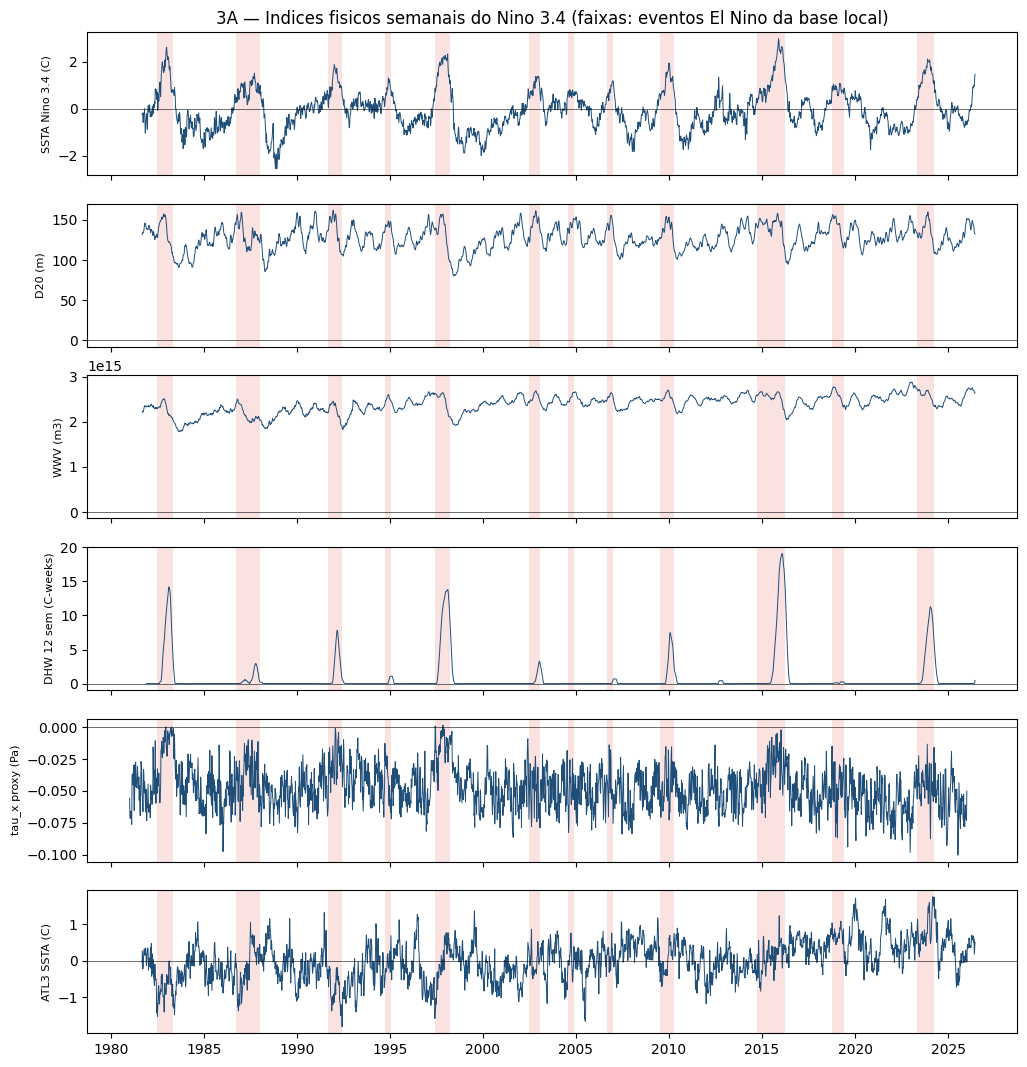

In [3]:
# Figura 3A-1: painel de series semanais com eventos El Nino sombreados
ev = u.load_events()
panels = [('nino34_ssta','SSTA Nino 3.4 (C)'), ('d20_m','D20 (m)'), ('wwv','WWV (m3)'),
          ('dhw_12w','DHW 12 sem (C-weeks)'), ('tau_x_proxy_nino34_pa','tau_x proxy (Pa)'),
          ('atl3_ssta','ATL3 SSTA (C)')]
fig, axes = plt.subplots(len(panels), 1, figsize=(12, 13), sharex=True)
for ax, (col, label) in zip(axes, panels):
    ax.plot(weekly.index, weekly[col], lw=0.7, color='#1f4e79')
    u.add_event_shading(ax, ev)
    ax.set_ylabel(label, fontsize=8)
    ax.axhline(0, color='k', lw=0.4)
axes[0].set_title('3A — Indices fisicos semanais do Nino 3.4 (faixas: eventos El Nino da base local)')
u.save_fig(fig, 'phase3A_series_semanais.png')
plt.show()

[figura] data/processed/figures/fase3/phase3A_hovmoller_panorama.png


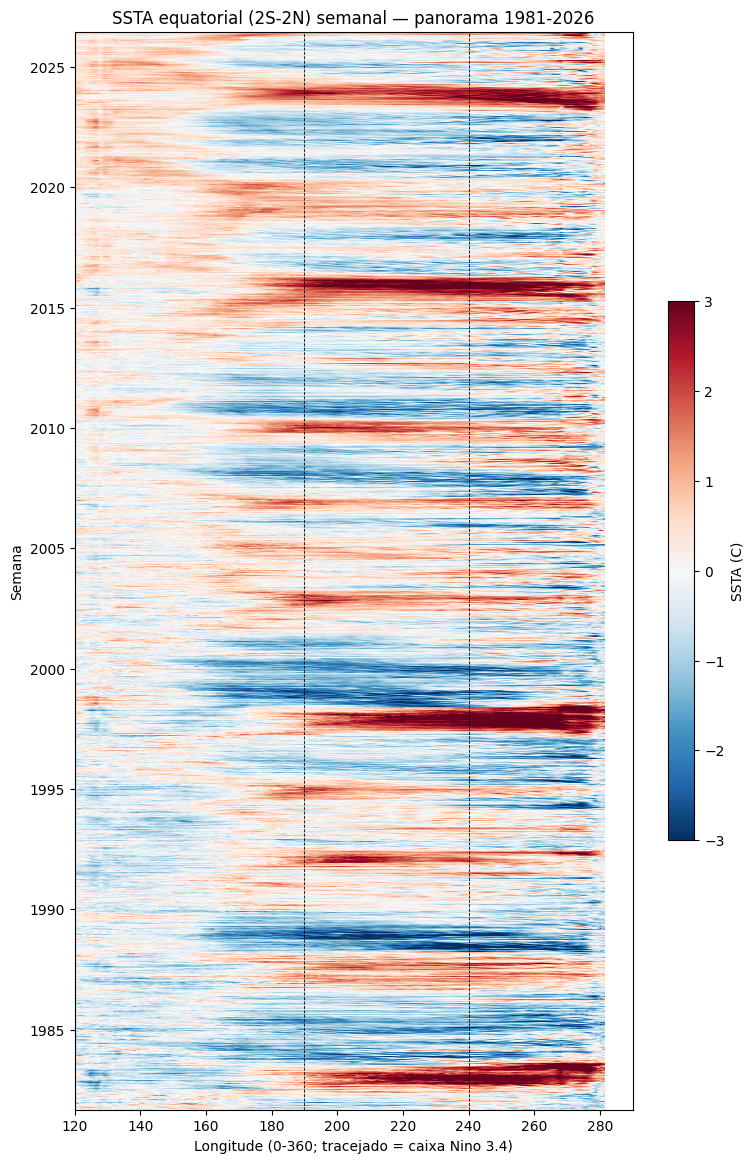

In [4]:
# Mapa 3A-1: Hovmoller panoramico da SSTA equatorial (2S-2N) 1981-2026
eq = u.load_eqband_weekly()
fig, ax = plt.subplots(figsize=(9, 14))
lon = eq.columns.values
pc = ax.pcolormesh(lon, eq.index, eq.values, cmap='RdBu_r', vmin=-3, vmax=3, shading='auto')
ax.axvline(190, color='k', ls='--', lw=0.6); ax.axvline(240, color='k', ls='--', lw=0.6)
ax.set_xlabel('Longitude (0-360; tracejado = caixa Nino 3.4)'); ax.set_ylabel('Semana')
ax.set_title('SSTA equatorial (2S-2N) semanal — panorama 1981-2026')
fig.colorbar(pc, ax=ax, label='SSTA (C)', shrink=0.5)
u.save_fig(fig, 'phase3A_hovmoller_panorama.png')
plt.show()

**Leitura do 3A.** A matriz semanal cobre 1981–2026 na superfície (SSTA, ATL, DHW, τx) e 1981–2026 na subsuperfície com a ressalva de emenda de fontes (UFS→GLORYS12 em 1993): qualquer conclusão subsuperficial deve ser reavaliada na janela 1993+. O Hovmöller panorâmico mostra os aquecimentos de 1982/83, 1997/98, 2015/16 e 2023/24 como faixas quentes atravessando a caixa Niño 3.4 (tracejado), justificando o desenho de precursores por longitude no 3C. Esta matriz é o insumo único dos notebooks 3B–3G — nenhum deles refaz agregação própria, o que garante consistência entre respostas.